In [1]:
pip install scipy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 12.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 18.7 MB/s eta 0:00:0000:010:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scikit-learn numpy seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 6.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 12.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 16.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [172]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score,recall_score,precision_score,accuracy_score, \
confusion_matrix,ConfusionMatrixDisplay,classification_report

from scipy.special import logit
import seaborn as sns
import matplotlib.pyplot as plt

In [173]:
df = pd.read_csv("waze_dataset.csv")
df.head(10)

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android
5,5,retained,113,103,279.544437,2637,0,0,901.238699,439.101397,15,11,iPhone
6,6,retained,3,2,236.725314,360,185,18,5249.172828,726.577205,28,23,iPhone
7,7,retained,39,35,176.072845,2999,0,0,7892.052468,2466.981741,22,20,iPhone
8,8,retained,57,46,183.532018,424,0,26,2651.709764,1594.342984,25,20,Android
9,9,churned,84,68,244.802115,2997,72,0,6043.460295,2341.838528,7,3,iPhone


In [174]:
map_dict = {"Android":2,"iPhone":1}

df["device_type"] = df["device"]
df["device_type"] = df["device_type"].map(map_dict)
df["device_type"]

0        2
1        1
2        2
3        1
4        2
        ..
14994    1
14995    2
14996    1
14997    1
14998    1
Name: device_type, Length: 14999, dtype: int64

In [175]:
df.groupby("device_type")["drives"].mean()

device_type
1    67.859078
2    66.231838
Name: drives, dtype: float64

In [176]:
iPhone = df[df["device_type"] ==1]["drives"]
Android =df[df["device_type"] ==2]["drives"]

stats.ttest_ind(a =Android,b = iPhone, equal_var=False)

TtestResult(statistic=np.float64(-1.463523206885235), pvalue=np.float64(0.143351972680206), df=np.float64(11345.066049381952))

In [177]:
# Exploratory data analysis
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,device_type
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android,2
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone,1
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android,2
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone,1
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android,2


In [178]:
df = df.drop(columns = "ID")

In [179]:
df.groupby("label")["drives"].mean()

label
churned     72.730678
retained    66.075491
Name: drives, dtype: float64

In [180]:
df.describe()

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device_type
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879,1.355157
std,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036,0.478577
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,1.000000
25%,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000,1.000000
50%,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000,1.000000
75%,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000,2.000000
max,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000,2.000000


In [181]:
df["km_per_driving_day"] = df["driven_km_drives"]/df["driving_days"]
df["km_per_driving_day"].describe()


/srv/conda/envs/notebook/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.231459e+02
75%      7.579257e+02
max               inf
Name: km_per_driving_day, dtype: float64

In [182]:
df.loc[df["km_per_driving_day"] == np.inf,"km_per_driving_day"]=0
df["km_per_driving_day"].describe()

count    14999.000000
mean       578.963113
std       1030.094384
min          0.000000
25%        136.238895
50%        272.889272
75%        558.686918
max      15420.234110
Name: km_per_driving_day, dtype: float64

In [183]:
df["professional_driver"] = np.where((df["drives"]>=60) & (df["driving_days"] >15),1,0)
df["professional_driver"] 

0        1
1        0
2        0
3        0
4        1
        ..
14994    0
14995    0
14996    1
14997    0
14998    0
Name: professional_driver, Length: 14999, dtype: int64

In [184]:
df["professional_driver"].value_counts()
df["label_numeric"] = df["label"].map({"churned":1,"retained":0})

df.groupby("professional_driver")["label_numeric"].mean() * 100

professional_driver
0    19.766958
1     7.049037
Name: label_numeric, dtype: float64

In [185]:
# Model Construction and variables preperation
df["label"].info()


<class 'pandas.core.series.Series'>
RangeIndex: 14999 entries, 0 to 14998
Series name: label
Non-Null Count  Dtype 
--------------  ----- 
14299 non-null  object
dtypes: object(1)
memory usage: 117.3+ KB


In [186]:
df["label"].dropna()

0        retained
1        retained
2        retained
3        retained
4        retained
           ...   
14994    retained
14995    retained
14996    retained
14997     churned
14998    retained
Name: label, Length: 14299, dtype: object

In [187]:
for col in ["sessions",
"drives",
"total_sessions",
"total_navigations_fav1",
"total_navigations_fav2",
"driven_km_drives",
"duration_minutes_drives"]:
    percentile_95 = df[col].quantile(0.95)
    df.loc[df[col] > percentile_95,col] = percentile_95

In [188]:
df.describe()

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device_type,km_per_driving_day,professional_driver,label_numeric
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14299.000000
mean,76.568705,64.058204,184.031320,1749.837789,114.415228,27.214281,3939.632764,1789.647426,15.537102,12.179879,1.355157,578.963113,0.158877,0.177355
std,67.297958,55.306924,118.600463,1008.513876,124.686795,36.735583,2216.041510,1222.705167,9.004655,7.824036,0.478577,1030.094384,0.365574,0.381982
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000,1.000000,136.238895,0.000000,0.000000
50%,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000,1.000000,272.889272,0.000000,0.000000
75%,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000,2.000000,558.686918,0.000000,0.000000
max,243.000000,201.000000,454.363204,3500.000000,424.000000,124.000000,8889.794236,4668.899349,31.000000,30.000000,2.000000,15420.234110,1.000000,1.000000


In [189]:
df["label_2"] = np.where(df["label"] == "retained",0,1)


In [190]:
df.corr(method="pearson",numeric_only = True)

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device_type,km_per_driving_day,professional_driver,label_numeric,label_2
sessions,1.000000,0.996907,0.595796,0.006480,0.003123,0.009746,0.001425,-0.005364,0.024374,0.018518,-0.010453,-0.011099,0.420720,0.034911,0.031702
drives,0.996907,1.000000,0.593945,0.006198,0.002307,0.010365,0.001789,-0.004763,0.023821,0.018036,-0.009457,-0.010609,0.421296,0.035943,0.033292
total_sessions,0.595796,0.593945,1.000000,0.005328,0.002377,0.008061,-0.000835,-0.001456,0.015932,0.012568,-0.010012,-0.014563,0.240126,0.024568,0.027666
n_days_after_onboarding,0.006480,0.006198,0.005328,1.000000,0.001232,-0.007468,-0.002852,-0.009140,-0.009725,-0.008563,0.012044,0.011631,0.001725,-0.129263,-0.118200
total_navigations_fav1,0.003123,0.002307,0.002377,0.001232,1.000000,0.002467,-0.007898,0.002722,0.012176,0.011339,-0.002030,-0.002056,0.005871,0.052389,0.042573
total_navigations_fav2,0.009746,0.010365,0.008061,-0.007468,0.002467,1.000000,0.003831,-0.000951,-0.003489,0.003197,0.002156,0.004308,0.007246,0.015032,0.014704
driven_km_drives,0.001425,0.001789,-0.000835,-0.002852,-0.007898,0.003831,1.000000,0.690996,-0.005620,-0.007816,0.000526,0.343509,-0.002186,0.019771,0.013660
duration_minutes_drives,-0.005364,-0.004763,-0.001456,-0.009140,0.002722,-0.000951,0.690996,1.000000,-0.005852,-0.007585,0.007708,0.238133,-0.010030,0.040406,0.030675
activity_days,0.024374,0.023821,0.015932,-0.009725,0.012176,-0.003489,-0.005620,-0.005852,1.000000,0.947706,0.009296,-0.397062,0.452389,-0.303851,-0.270926
driving_days,0.018518,0.018036,0.012568,-0.008563,0.011339,0.003197,-0.007816,-0.007585,0.947706,1.000000,0.003558,-0.407633,0.470983,-0.294259,-0.261467


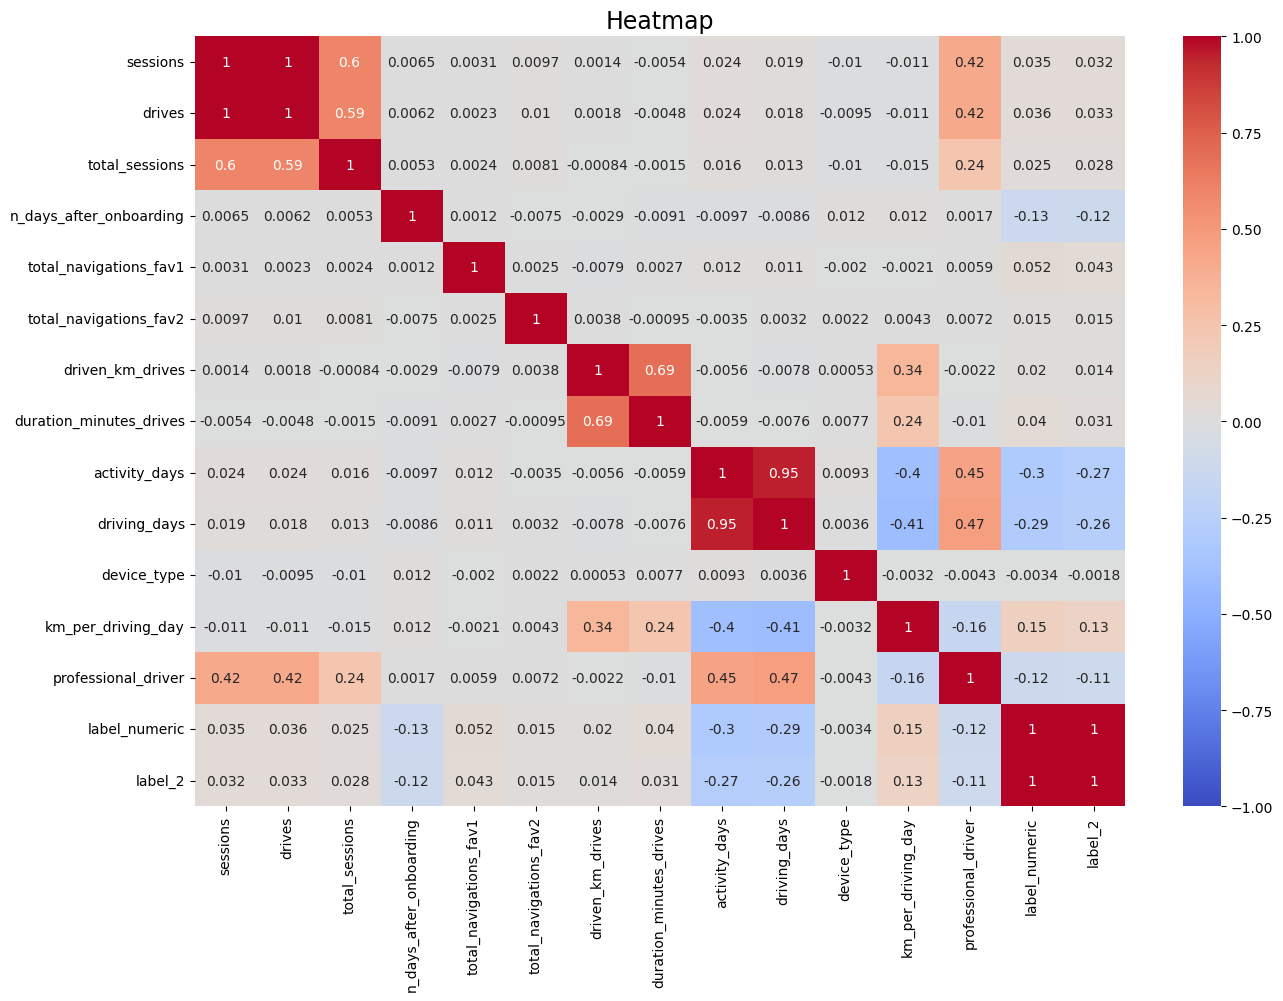

In [191]:
plt.figure(figsize = (15,10))
sns.heatmap(df.corr(method = "pearson",numeric_only =True),vmin =-1,vmax =1,cmap="coolwarm",annot =True)
plt.title("Heatmap",fontsize = 17)
plt.show()

In [192]:
df["device2"] = np.where(df["device"] == "Android",0,1)
df[["device","device2"]].tail()

,device,device2
14994,iPhone,1
14995,Android,0
14996,iPhone,1
14997,iPhone,1
14998,iPhone,1


In [193]:
df = df.dropna()
X = df.drop(columns = ["label", "label_2","device","sessions","driving_days","label_numeric"])

In [194]:
y = df["label_2"]


In [195]:
X_train,X_test,y_train,y_test = train_test_split(X,y,stratify = y,random_state = 42)

In [196]:

X_train.head()

,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,device_type,km_per_driving_day,professional_driver,device2
152,108,186.192746,3116,243,124,8889.794236,4668.899349,24,1,612.305861,0,1
11899,2,3.487590,794,114,18,3286.545691,1780.902733,5,1,3286.545691,0,1
10937,139,347.106403,331,4,7,7400.838975,2349.305267,15,2,616.736581,0,0
669,108,454.363204,2320,11,4,6566.424830,4558.459870,18,1,410.401552,1,1
8406,10,89.475821,2478,135,0,1271.248661,938.711572,27,1,74.779333,0,1


In [197]:
model = LogisticRegression(max_iter = 400,penalty=None)


In [198]:
model.fit(X_train,y_train)

/srv/conda/envs/notebook/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 400 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=400).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,400
,multi_class,'deprecated'


In [199]:
pd.Series(model.coef_[0],index = X.columns)

drives                     0.001968
total_sessions             0.000353
n_days_after_onboarding   -0.000401
total_navigations_fav1     0.001252
total_navigations_fav2     0.000981
driven_km_drives          -0.000013
duration_minutes_drives    0.000110
activity_days             -0.105468
device_type               -0.023319
km_per_driving_day         0.000019
professional_driver       -0.007563
device2                    0.001222
dtype: float64

In [200]:
model.intercept_

array([-0.01104842])

In [201]:
train_prob = model.predict_proba(X_train)




In [202]:
logit_data = X_train.copy()

eplison = 1e-10
logit_data["logit"] = [np.log((prob[1] + eplison)/(prob[0] + eplison)) for prob in train_prob] 

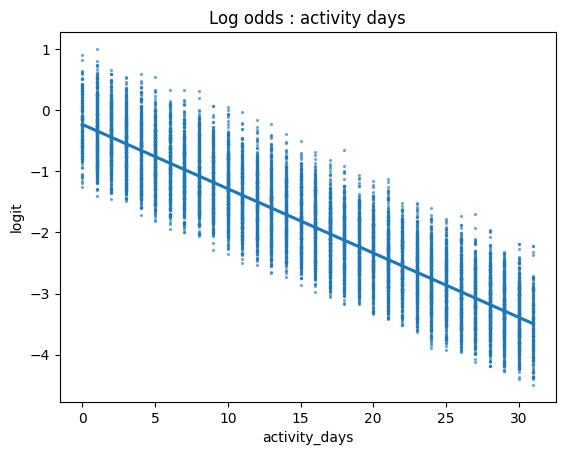

In [203]:
sns.regplot(x = "activity_days",y = "logit", data = logit_data,scatter_kws ={"s":2,"alpha":0.5})
plt.title("Log odds : activity days")
plt.show()

In [204]:
y_pred = model.predict(X_test)

In [205]:
model.score(X_test,y_test)

0.8246153846153846

In [206]:
cm = confusion_matrix(y_test,y_pred)


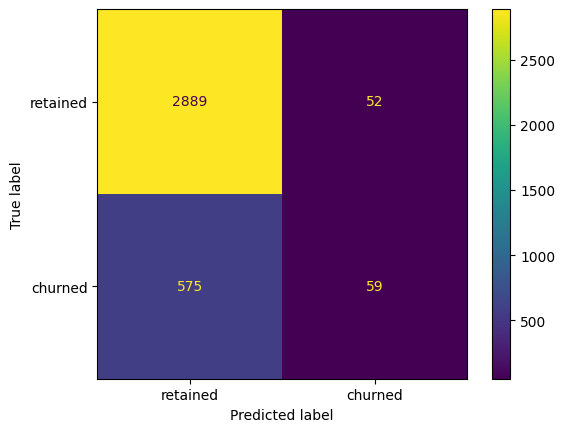

In [207]:
disp = ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = ["retained","churned"])
disp.plot()

In [208]:
precision = cm[1,1] /(cm[0,1] + cm[1,1])
precision

np.float64(0.5315315315315315)

In [209]:
recall = cm[1,1] /(cm[1,0] + cm[1,1])
recall

np.float64(0.09305993690851735)

In [211]:
target_label = ["retained","churned"]
print(classification_report(y_test,y_pred,target_names = target_label))
#Note: The model has mediocre precision and very low recall, which means that it makes a lot of false negative predictions and fails to capture users who will churn.

              precision    recall  f1-score   support

    retained       0.83      0.98      0.90      2941
     churned       0.53      0.09      0.16       634

    accuracy                           0.82      3575
   macro avg       0.68      0.54      0.53      3575
weighted avg       0.78      0.82      0.77      3575



In [212]:
feature_impt = list(zip(X_train.columns,model.coef_[0]))
feature_impt = sorted(feature_impt,key = lambda x : x[1],reverse = True)
feature_impt

[('drives', np.float64(0.0019681295946034193)),
 ('total_navigations_fav1', np.float64(0.001252337080829817)),
 ('device2', np.float64(0.0012223461233791917)),
 ('total_navigations_fav2', np.float64(0.000981325098779954)),
 ('total_sessions', np.float64(0.0003528908410388496)),
 ('duration_minutes_drives', np.float64(0.0001101484042784159)),
 ('km_per_driving_day', np.float64(1.9118100299654862e-05)),
 ('driven_km_drives', np.float64(-1.2981382662741219e-05)),
 ('n_days_after_onboarding', np.float64(-0.0004014997671722426)),
 ('professional_driver', np.float64(-0.007563216942764942)),
 ('device_type', np.float64(-0.0233191808832098)),
 ('activity_days', np.float64(-0.10546811500985544))]

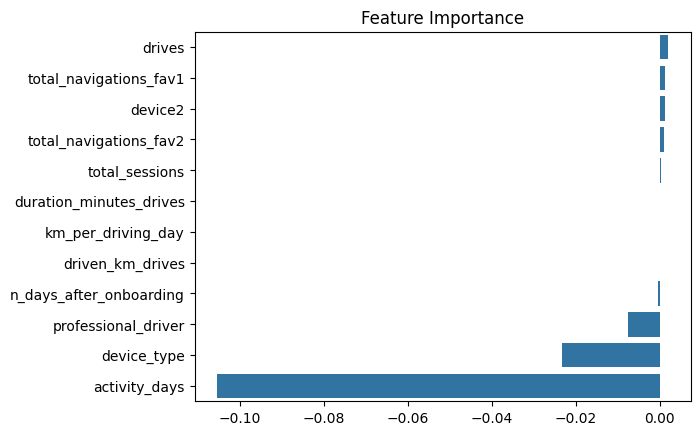

In [213]:
sns.barplot(x = [x[1] for x in feature_impt],
            y = [x[0] for x in feature_impt])
plt.title("Feature Importance")
plt.show()